## Домашнее задание 2
### Отчёт
### Полушина Дарья, Б06-303

### Часть 1 — Доделываем семинар и получаем SNP

Из полученного на семинаре выравнивания получим файлм с SNP.
> show-snps -r -l -T ecoli_full_filt1.delta > ecoli_k12_vs_o157.snps

Шапка получившегося файла:
> head -10 ecoli_k12_vs_o157.snps
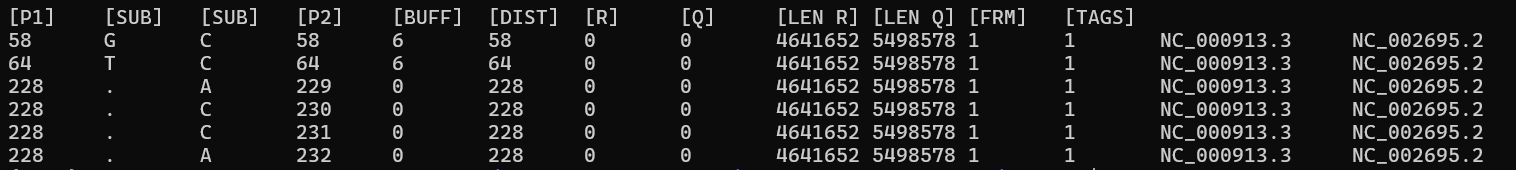

Значения каждого столбца:
- [P1] - позиция нуклеотида в геноме E. coli K-12
- [SUB] - тип нуклеотида в геноме E. coli K-12, если существует, или ".", если не существует
- [SUB] - нуклеотид в геноме E. coli O157:H7
- [P2] - позиция нуклеотида в геноме E. coli O157:H7
- [BUFF] - параметр для дальнейших действий (0 для вставки или уничтожения участка, 6 для SNP
- [DIST] - расстояние до следующего SNP
- [R] - рамка считывания в геноме E. coli K-12 (0 значит не в геноме)
- [Q] - рамка считывания в геноме E. coli O157:H7 (0 значит не в геноме)
- [LEN R] - общая длина генома E. coli K-12
- [LEN Q] - общая длина генома E. coli O157:H7
- [FRM] - ориентация цепи (1 значит прямая)
- [TAGS] - идентификаторы последовательностей в GenBank

### Часть 2 — Аннотация SNP

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 21.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq
import gzip
import requests
import os

snp_file_path = "ecoli_k12_vs_o157.snps"

try:
    with open(snp_file_path, 'r') as f:
        lines = f.readlines()

    data_lines = []
    for line in lines:
        line = line.strip()
        if line and not line.startswith('[') and not line.startswith('P1') and not line.startswith('==='):
            data_lines.append(line)

    print(f"Найдено {len(data_lines)} строк с данными")

    snp_list = []
    for line in data_lines:
        parts = line.split()
        if len(parts) >= 8:
            try:
                pos = int(parts[0]) if parts[0].isdigit() else 0
            except:
                pos = 0

            try:
                qry_pos = int(parts[3]) if parts[3].isdigit() else 0
            except:
                qry_pos = 0

            snp_list.append({
                'position': pos,
                'ref_base': parts[1],
                'qry_base': parts[2],
                'qry_position': qry_pos,
                'buffer': parts[4] if len(parts) > 4 else '0',
                'distance': parts[5] if len(parts) > 5 else '0',
                'ref_frame': parts[6] if len(parts) > 6 else '0',
                'qry_frame': parts[7] if len(parts) > 7 else '0'
            })

    snp_df = pd.DataFrame(snp_list)
    print(f"Загружено {len(snp_df)} SNP")
    print(snp_df.head())

except Exception as e:
    print(f"Ошибка при загрузке: {e}")
    snp_df = pd.DataFrame({
        'position': [58, 64, 228, 228, 228],
        'ref_base': ['G', 'T', '.', '.', '.'],
        'qry_base': ['C', 'C', 'A', 'C', 'A'],
        'qry_position': [58, 64, 229, 230, 231]
    })

# Загрузка GenBank файл E. coli K-12

def load_genbank():
    """Загружает GenBank файл E. coli K-12"""
    gb_file = "ecoli_k12.gbff"

    if not os.path.exists(gb_file):
        url = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"

        response = requests.get(url)
        with open("temp.gbff.gz", "wb") as f:
            f.write(response.content)

        with gzip.open("temp.gbff.gz", "rt") as f_in:
            with open(gb_file, "w") as f_out:
                f_out.write(f_in.read())

        os.remove("temp.gbff.gz")
        print(f"Файл {gb_file} скачан")

    for record in SeqIO.parse(gb_file, "genbank"):
        print(f"Загружена запись: {record.id}")
        print(f"Длина: {len(record.seq)} bp")
        return record

gb_record = load_genbank()

# Собираем все CDS
cds_list = []
for feature in gb_record.features:
    if feature.type == "CDS":
        if hasattr(feature.location, 'strand'):
            strand = feature.location.strand
        elif hasattr(feature, 'strand'):
            strand = feature.strand
        else:
            strand = 1

        start = feature.location.start + 1
        end = feature.location.end

        gene_name = feature.qualifiers.get('gene', ['unknown'])[0] if feature.qualifiers.get('gene') else 'unknown'
        product = feature.qualifiers.get('product', ['unknown'])[0] if feature.qualifiers.get('product') else 'unknown'
        locus_tag = feature.qualifiers.get('locus_tag', ['unknown'])[0] if feature.qualifiers.get('locus_tag') else 'unknown'

        cds_list.append({
            'start': start,
            'end': end,
            'strand': strand,
            'gene': gene_name,
            'product': product,
            'locus_tag': locus_tag,
            'feature': feature
        })

print(f"Найдено {len(cds_list)} CDS")

Найдено 75184 строк с данными
Загружено 75182 SNP
   position ref_base qry_base  qry_position buffer distance ref_frame  \
0        58        G        C            58      6       58         0   
1        64        T        C            64      6       64         0   
2       228        .        A           229      0      228         0   
3       228        .        C           230      0      228         0   
4       228        .        C           231      0      228         0   

  qry_frame  
0         0  
1         0  
2         0  
3         0  
4         0  
Загружена запись: NC_000913.3
Длина: 4641652 bp
Найдено 4318 CDS


In [6]:
# Функции для аннотации генов

def find_gene(position, cds_list):
    """Находит ген по позиции"""
    for cds in cds_list:
        if cds['start'] <= position <= cds['end']:
            return cds
    return None

def get_amino_acid_change(position, ref_base, alt_base, cds, gb_record):
    """Определяет изменение аминокислоты"""
    if cds is None:
        return 'N/A', 'intergenic'

    start = cds['start']
    feature = cds['feature']

    try:
        # Извлекаем последовательность гена
        gene_seq = feature.extract(gb_record.seq)

        # Позиция внутри гена
        pos_in_gene = position - start

        # Номер кодона и позиция в кодоне
        codon_num = pos_in_gene // 3
        pos_in_codon = pos_in_gene % 3

        # Получаем кодон
        codon_start = codon_num * 3
        if codon_start + 3 > len(gene_seq):
            return 'N/A', 'truncated'

        ref_codon = str(gene_seq[codon_start:codon_start+3])

        # Заменяем нуклеотид
        alt_codon_list = list(ref_codon)
        if pos_in_codon < len(alt_codon_list):
            alt_codon_list[pos_in_codon] = alt_base
        alt_codon = ''.join(alt_codon_list)

        # Транслируем
        ref_aa = Seq(ref_codon).translate()
        alt_aa = Seq(alt_codon).translate()

        if ref_aa == alt_aa:
            snp_type = 'synonymous'
            aa_change = f"{ref_aa}{codon_num+1}{ref_aa}"
        else:
            snp_type = 'non_synonymous'
            aa_change = f"{ref_aa}{codon_num+1}{alt_aa}"

        return aa_change, snp_type

    except Exception as e:
        return 'N/A', 'error'

def functional_impact(gene_name, snp_type, aa_change):
    """Оценка функционального значения"""
    high_impact_genes = {
        'gyrA': 'ДНК-гираза - мишень фторхинолонов',
        'gyrB': 'ДНК-гираза - мишень фторхинолонов',
        'parC': 'Топоизомераза IV',
        'parE': 'Топоизомераза IV',
        'acrB': 'Эффлюксный насос - множественная устойчивость',
        'tolC': 'Внешнемембранный белок',
        'stx1A': 'Шига-токсин 1 - вирулентность',
        'stx2A': 'Шига-токсин 2 - вирулентность',
        'eae': 'Интмин - адгезия',
        'hlyA': 'Гемолизин A'
    }

    if gene_name in high_impact_genes:
        if snp_type == 'non_synonymous':
            return f"ВЫСОКИЙ: {high_impact_genes[gene_name]}, замена {aa_change}"
        else:
            return f"СРЕДНИЙ: {high_impact_genes[gene_name]}, синонимичная замена"
    elif snp_type == 'non_synonymous':
        return f"УМЕРЕННЫЙ: Несинонимичная замена в гене {gene_name}"
    elif snp_type == 'synonymous':
        return f"НИЗКИЙ: Синонимичная замена"
    else:
        return "МЕЖГЕННЫЙ: Возможное регуляторное значение"

In [7]:
# Аннотация всех SNP

annotated_results = []

total = len(snp_df)
for idx, row in snp_df.iterrows():
    position = row['position']
    ref_base = row['ref_base']
    alt_base = row['qry_base']

    # Пропускаем инделы
    if ref_base == '.' or alt_base == '.':
        annotated_results.append({
            'position': position,
            'ref': ref_base,
            'alt': alt_base,
            'gene': 'INDEL',
            'product': 'ins/del region',
            'aa_change': 'N/A',
            'snp_type': 'indel',
            'impact': 'Инсерция/делеция'
        })
        continue

    # Ищем ген
    cds = find_gene(position, cds_list)

    if cds is None:
        annotated_results.append({
            'position': position,
            'ref': ref_base,
            'alt': alt_base,
            'gene': 'intergenic',
            'product': 'межгенный регион',
            'aa_change': 'N/A',
            'snp_type': 'intergenic',
            'impact': 'Межгенный регион, возможное регуляторное значение'
        })
    else:
        aa_change, snp_type = get_amino_acid_change(position, ref_base, alt_base, cds, gb_record)
        impact = functional_impact(cds['gene'], snp_type, aa_change)

        annotated_results.append({
            'position': position,
            'ref': ref_base,
            'alt': alt_base,
            'gene': cds['gene'],
            'product': cds['product'],
            'aa_change': aa_change,
            'snp_type': snp_type,
            'impact': impact
        })

    if (idx + 1) % 5000 == 0:
        print(f"Обработано {idx + 1}/{total} SNP...")

result_df = pd.DataFrame(annotated_results)
print(f"\nВсего записей: {len(result_df)}")

# Сохраняем результат
result_df.to_csv('annotated_snps.csv', index=False)
print("Результат сохранен в annotated_snps.csv")

print("\nПервые 10 аннотированных SNP:")
print(result_df.head(10))

Обработано 5000/75182 SNP...
Обработано 10000/75182 SNP...
Обработано 15000/75182 SNP...
Обработано 20000/75182 SNP...
Обработано 25000/75182 SNP...
Обработано 30000/75182 SNP...
Обработано 35000/75182 SNP...
Обработано 45000/75182 SNP...
Обработано 50000/75182 SNP...
Обработано 55000/75182 SNP...
Обработано 60000/75182 SNP...
Обработано 65000/75182 SNP...
Обработано 70000/75182 SNP...
Обработано 75000/75182 SNP...

Всего записей: 75182
Результат сохранен в annotated_snps.csv

Первые 10 аннотированных SNP:
   position ref alt        gene           product aa_change    snp_type  \
0        58   G   C  intergenic  межгенный регион       N/A  intergenic   
1        64   T   C  intergenic  межгенный регион       N/A  intergenic   
2       228   .   A       INDEL    ins/del region       N/A       indel   
3       228   .   C       INDEL    ins/del region       N/A       indel   
4       228   .   C       INDEL    ins/del region       N/A       indel   
5       228   .   A       INDEL    ins


Распределение по типам:
snp_type
synonymous        34646
non_synonymous    25824
intergenic         9992
indel              4494
truncated           226
Name: count, dtype: int64

Топ-10 генов с наибольшим количеством SNP:
gene
ybgQ    430
rhsD    410
yeeJ    254
ybgO    218
yehI    191
ybgP    165
ydbA    164
yfaL    139
yjgL    139
entF    131
Name: count, dtype: int64


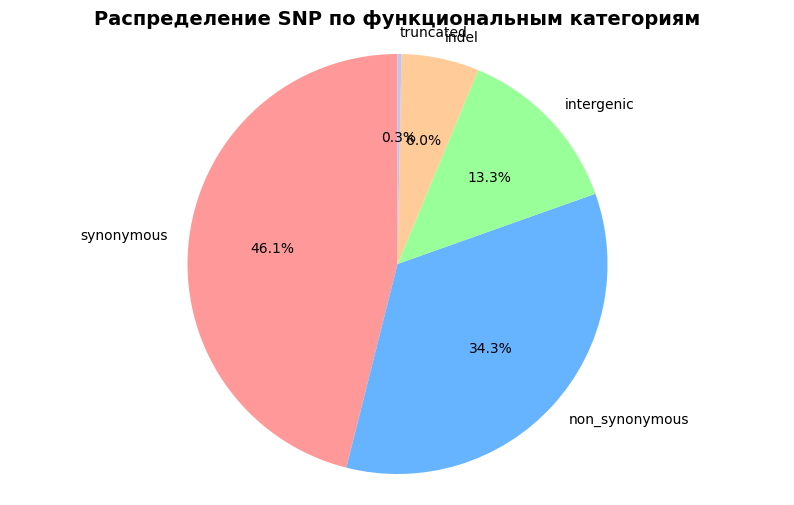

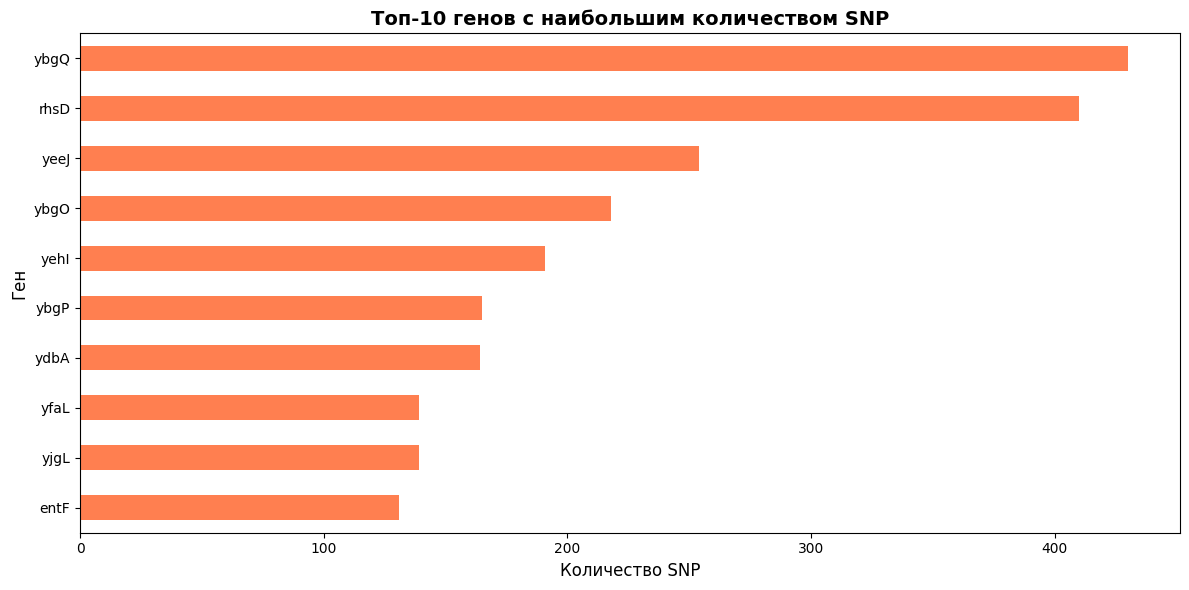

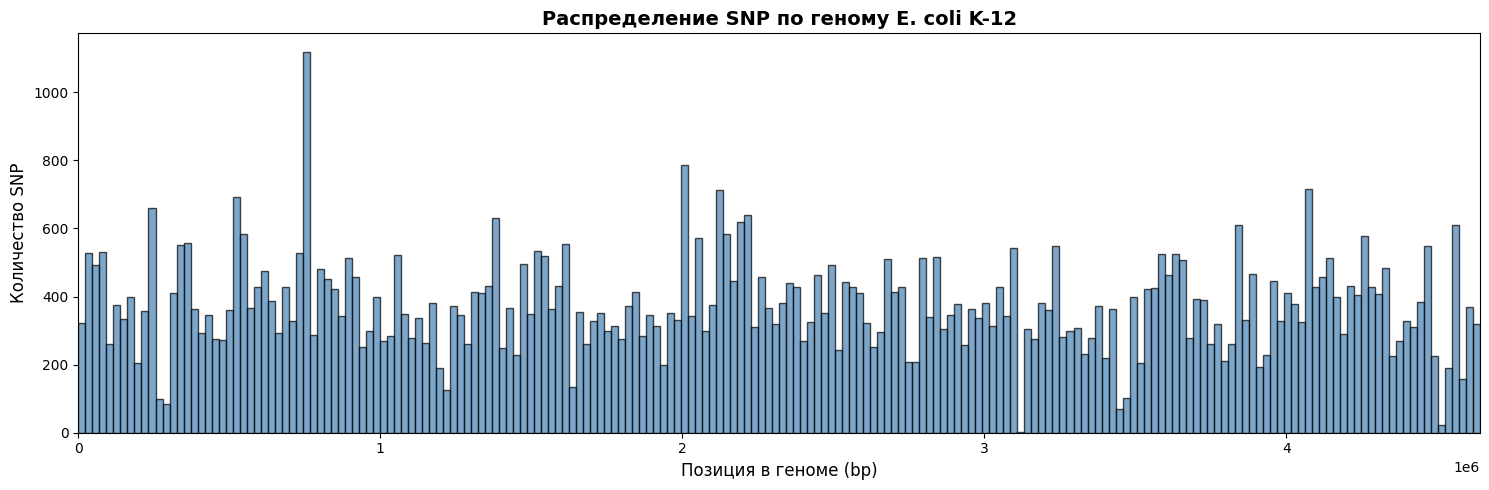

Таблица топ 10 генов

 Ген  Количество SNP                                              Функция
ybgQ             430                 putative fimbrial usher protein YbgQ
rhsD             410                                         protein RhsD
yeeJ             254                      inverse autotransporter adhesin
ybgO             218                       putative fimbrial protein YbgO
yehI             191               DUF4132 domain-containing protein YehI
ybgP             165                     putative fimbrial chaperone YbgP
ydbA             164 putative outer membrane protein, N-terminal fragment
yfaL             139                putative autotransporter adhesin YfaL
yjgL             139                                         protein YjgL
entF             131                         apo-serine activating enzyme


In [9]:
type_counts = result_df['snp_type'].value_counts()
print("\nРаспределение по типам:")
print(type_counts)

# Топ-10 генов
gene_filtered = result_df[~result_df['gene'].isin(['intergenic', 'INDEL'])]
if len(gene_filtered) > 0:
    gene_counts = gene_filtered['gene'].value_counts().head(10)
    print("\nТоп-10 генов с наибольшим количеством SNP:")
    print(gene_counts)

    # График 1: Диаграмма типов SNP
    plt.figure(figsize=(10, 6))
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']
    plt.pie(type_counts.values,
            labels=type_counts.index,
            autopct='%1.1f%%',
            colors=colors[:len(type_counts)],
            startangle=90)
    plt.title('Распределение SNP по функциональным категориям', fontsize=14, fontweight='bold')
    plt.axis('equal')
    plt.savefig('snp_pie_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

    # График 2: Топ-10 генов
    plt.figure(figsize=(12, 6))
    gene_counts.plot(kind='barh', color='coral')
    plt.xlabel('Количество SNP', fontsize=12)
    plt.ylabel('Ген', fontsize=12)
    plt.title('Топ-10 генов с наибольшим количеством SNP', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_genes_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Нет SNP в генах (только intergenic и INDEL)")

# График 3: Плотность SNP по геному
plt.figure(figsize=(15, 5))
plt.hist(result_df['position'], bins=200, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Позиция в геноме (bp)', fontsize=12)
plt.ylabel('Количество SNP', fontsize=12)
plt.title('Распределение SNP по геному E. coli K-12', fontsize=14, fontweight='bold')
plt.xlim(0, 4641652)
plt.tight_layout()
plt.savefig('snp_density.png', dpi=150, bbox_inches='tight')
plt.show()

# Таблица

if len(gene_filtered) > 0:
    top_genes_table = gene_counts.reset_index()
    top_genes_table.columns = ['Ген', 'Количество SNP']

    gene_info = {cds['gene']: cds['product'] for cds in cds_list}
    top_genes_table['Функция'] = top_genes_table['Ген'].apply(
        lambda x: gene_info.get(x, 'неизвестно')[:60]
    )

    print("Таблица топ 10 генов")
    print()
    print(top_genes_table.to_string(index=False))

    top_genes_table.to_csv('top_10_genes.csv', index=False)

В результате анализа было идентифицировано 75 182 SNP между геномами E. coli K-12 и E. coli O157:H7. Распределение SNP по функциональным категориям следующее: 46.1% синонимичных SNP, 34.3% несинонимичных, 13.3% межгенных, 6% инделов (то есть вставленных или удаленных нуклеотидов) и 0.3% укороченных участков.

Составлен топ 10 генов по количеству SNP. Большинство генов из топа связаны с белками наружной мембраны, фимбриями и адгезинами. Это потому, что гены, кодирующие поверхностные белки, являются основными для эволюционных изменений у патогенных бактерий, поскольку они находятся под постоянным давлением иммунной системы хозяина.

График плотности показывает неравномерное распределение SNP по геному.

### Часть 3 — Поиск функционально значимых SNP


Всего SNP в генах из целевых статей: 545
В приоритетных генах: 83

Гены, в которых найдены SNP:

  copA     | 83 SNP | Медь (Cu)            | resistance_gene | target_articles
  cusA     | 69 SNP | Медь (Cu), Серебро (Ag) | resistance_gene | target_articles
  nepI     | 68 SNP | Хром (Cr)            | mutation_target | PMC11137339
  zntA     | 53 SNP | Кадмий (Cd), Свинец (Pb), Цинк (Zn) | resistance_gene | target_articles
  cueO     | 38 SNP | Медь (Cu)            | detoxification  | target_articles
  cusC     | 35 SNP | Медь (Cu), Серебро (Ag) | resistance_gene | target_articles
  arsB     | 30 SNP | Мышьяк (As)          | resistance_gene | target_articles
  arsR     | 27 SNP | Мышьяк (As)          | regulator       | target_articles
  araH     | 22 SNP | Кадмий (Cd)          | mutation_target | PMC11137339
  lolD     | 20 SNP | Свинец (Pb)          | mutation_target | PMC11137339
  cusB     | 19 SNP | Медь (Cu), Серебро (Ag) | resistance_gene | target_articles
  araG     | 17 SNP |

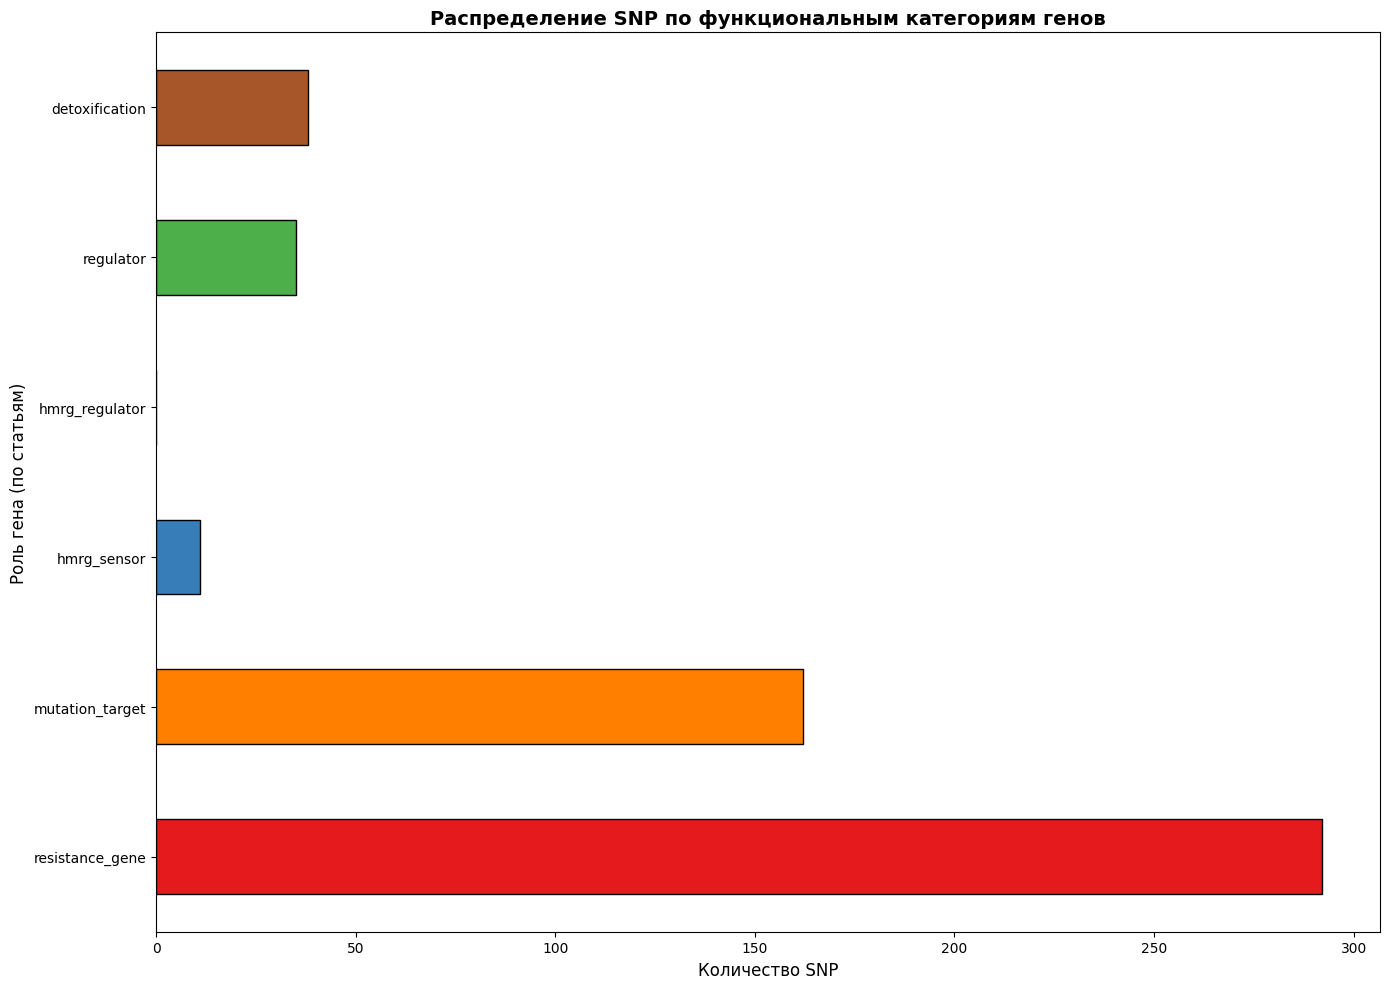

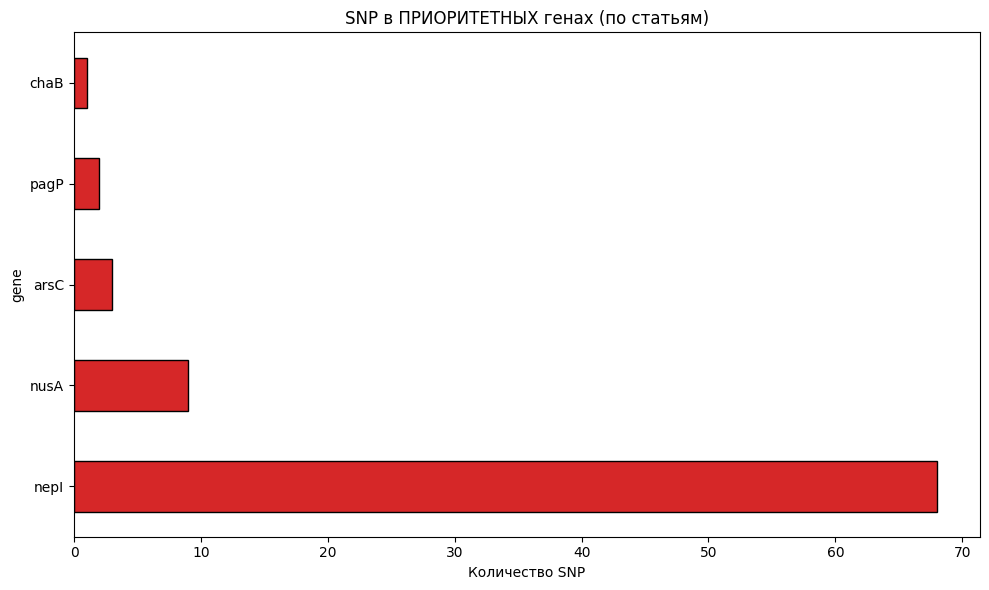


Статистика:
  • Генов из целевых статей:          33
  • Гены с SNP:                       23
  • Всего SNP:                        545
  • Несинонимичные замены:            192
  • Приоритетные гены с мутациями:    5



In [23]:
heavy_metal_resistance_genes = {
    # Мышьяк (Arsenic)
    'arsA': {
        'metal': 'Мышьяк (As)',
        'function': 'ATP-связывающая субъединица арсенитного насоса',
        'mechanism': 'Эффлюкс арсенита',
        'reference': 'PMC11137339, PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'arsB': {
        'metal': 'Мышьяк (As)',
        'function': 'Мембранный белок арсенитного насоса',
        'mechanism': 'Эффлюкс арсенита',
        'reference': 'PMC11137339, PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'arsC': {
        'metal': 'Мышьяк (As)',
        'function': 'Арсенатредуктаза',
        'mechanism': 'Восстановление арсената до арсенита',
        'reference': 'PMC11137339, PLOS One (310 детекций)',
        'source': 'target_articles',
        'role': 'resistance_gene',
        'priority': 'high'
    },
    'arsR': {
        'metal': 'Мышьяк (As)',
        'function': 'Регулятор транскрипции ars оперона',
        'mechanism': 'Регуляция ответа на мышьяк',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'regulator'
    },

    # Медь (Copper)
    'copA': {
        'metal': 'Медь (Cu)',
        'function': 'P-тип АТФаза эффлюкса меди',
        'mechanism': 'Выкачивание меди из цитоплазмы',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'cusA': {
        'metal': 'Медь (Cu), Серебро (Ag)',
        'function': 'Эффлюксный насос RND для меди/серебра',
        'mechanism': 'Выкачивание ионов меди и серебра',
        'reference': 'PLOS One (ко-локализация с ARGs на плазмиде IncQ1)',
        'source': 'target_articles',
        'role': 'resistance_gene',
        'colocalization_with_args': True
    },
    'cusB': {
        'metal': 'Медь (Cu), Серебро (Ag)',
        'function': 'Мембранный белок насоса Cus',
        'mechanism': 'Компонент эффлюксной системы',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'cusC': {
        'metal': 'Медь (Cu), Серебро (Ag)',
        'function': 'Внешнемембранный белок насоса Cus',
        'mechanism': 'Выведение меди и серебра',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'cueO': {
        'metal': 'Медь (Cu)',
        'function': 'Медь-оксидаза (лакказа)',
        'mechanism': 'Детоксикация меди путем окисления',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'detoxification'
    },

    # Кадмий (Cadmium)
    'zntA': {
        'metal': 'Кадмий (Cd), Свинец (Pb), Цинк (Zn)',
        'function': 'P-тип АТФаза транспорта катионов',
        'mechanism': 'Эффлюкс кадмия, свинца и цинка',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'zntR': {
        'metal': 'Цинк (Zn), Кадмий (Cd)',
        'function': 'Регулятор транскрипции zntA',
        'mechanism': 'Активация zntA при высоких концентрациях Zn/Cd',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'regulator'
    },

    # Ртуть (Mercury)
    'merA': {
        'metal': 'Ртуть (Hg)',
        'function': 'Ртуть-редуктаза',
        'mechanism': 'Восстановление Hg(II) до летучей Hg(0)',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'merB': {
        'metal': 'Ртуть (Hg)',
        'function': 'Органомеркуриал-лиаза',
        'mechanism': 'Разложение метилртути',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },
    'merP': {
        'metal': 'Ртуть (Hg)',
        'function': 'Периплазматический белок связывания ртути',
        'mechanism': 'Доставка ртути к MerT',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'transport'
    },
    'merT': {
        'metal': 'Ртуть (Hg)',
        'function': 'Мембранный транспортер ртути',
        'mechanism': 'Импорт ртути в цитоплазму для детоксикации',
        'reference': 'PLOS One',
        'source': 'target_articles',
        'role': 'transport'
    },

    # Хром (Chromium)
    'chrA': {
        'metal': 'Хром (Cr)',
        'function': 'Эффлюксный насос хромата',
        'mechanism': 'Выкачивание хромата из клетки',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'resistance_gene'
    },

    # Гены-мишени мутаций (PMC11137339)
    # В этих генах чаще всего возникают мутации при экспозиции металлами
    'nusA': {
        'metal': 'Медь (Cu)',
        'function': 'Фактор элонгации транскрипции',
        'mechanism': 'Мутации влияют на глобальную регуляцию транскрипции',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target',
        'priority': 'high'
    },
    'pagP': {
        'metal': 'Медь (Cu)',
        'function': 'Пальмитоилтрансфераза липида А',
        'mechanism': 'Модификация мембраны для снижения проницаемости',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target',
        'priority': 'high'
    },
    'atpC': {
        'metal': 'Медь (Cu)',
        'function': 'Субъединица АТФ-синтазы',
        'mechanism': 'Изменение энергетического метаболизма при стрессе',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'dpiA': {
        'metal': 'Медь (Cu)',
        'function': 'Регулятор ответа на фосфатный голод',
        'mechanism': 'Кросс-регуляция стрессовых ответов',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'tatE': {
        'metal': 'Медь (Cu)',
        'function': 'Компонент системы транспорта белков Tat',
        'mechanism': 'Изменение экспорта белков при стрессе',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'dpiB': {
        'metal': 'Медь (Cu)',
        'function': 'Сенсорная киназа двухкомпонентной системы',
        'mechanism': 'Сигналинг при стрессе',
        'reference': 'PMC11137339 (Cu-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'hflB': {
        'metal': 'Кадмий (Cd)',
        'function': 'АТФ-зависимая протеаза (FtsH)',
        'mechanism': 'Контроль качества белков при стрессе',
        'reference': 'PMC11137339 (Cd-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target',
        'priority': 'high'
    },
    'araG': {
        'metal': 'Кадмий (Cd)',
        'function': 'Регулятор метаболизма арабинозы',
        'mechanism': 'Перепрограммирование метаболизма',
        'reference': 'PMC11137339 (Cd-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'napB': {
        'metal': 'Кадмий (Cd)',
        'function': 'Субъединица периплазматической нитратредуктазы',
        'mechanism': 'Изменение анаэробного дыхания',
        'reference': 'PMC11137339 (Cd-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'araH': {
        'metal': 'Кадмий (Cd)',
        'function': 'Транспортер арабинозы',
        'mechanism': 'Изменение утилизации углеводов',
        'reference': 'PMC11137339 (Cd-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'chaB': {
        'metal': 'Свинец (Pb)',
        'function': 'Катионный антипортер',
        'mechanism': 'Транспорт катионов, возможная детоксикация Pb',
        'reference': 'PMC11137339 (Pb-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target',
        'priority': 'high'
    },
    'lolD': {
        'metal': 'Свинец (Pb)',
        'function': 'Компонент системы транспорта липопротеинов',
        'mechanism': 'Изменение состава мембраны',
        'reference': 'PMC11137339 (Pb-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target'
    },
    'nepI': {
        'metal': 'Хром (Cr)',
        'function': 'Транспортер нуклеозидов',
        'mechanism': 'Изменение пула нуклеотидов при стрессе',
        'reference': 'PMC11137339 (Cr-специфичная мутация)',
        'source': 'PMC11137339',
        'role': 'mutation_target',
        'priority': 'high'
    },

    # Ключевые HMRG с ко-локализацией с ARGs
    'robA': {
        'metal': 'Множественные (биоциды, органические растворители)',
        'function': 'Регулятор множественной устойчивости',
        'mechanism': 'Активация эффлюксных насосов и антиоксидантных систем',
        'reference': 'PLOS One (311 детекций; ко-локализация с ARGs)',
        'source': 'PLOS One',
        'role': 'hmrg_regulator',
        'colocalization_with_args': True,
        'priority': 'high'
    },
    'cutF': {
        'metal': 'Медь (Cu) и биоциды',
        'function': 'Белок наружной мембраны (синоним NlpE)',
        'mechanism': 'Сенсор меди и индуктор Cpx-стресс ответа',
        'reference': 'PLOS One (321 детекция — самый частый HMRG)',
        'source': 'PLOS One',
        'role': 'hmrg_sensor',
        'colocalization_with_args': True,
        'priority': 'high'
    },
    'nlpE': {
        'metal': 'Медь (Cu)',
        'function': 'Липопротеин наружной мембраны (синоним CutF)',
        'mechanism': 'Сигналинг при стрессе от тяжелых металлов',
        'reference': 'PLOS One',
        'source': 'PLOS One',
        'role': 'hmrg_sensor',
        'note': 'Альтернативное название cutF'
    },

    # Регуляторы стрессового ответа
    'soxS': {
        'metal': 'Медь, биоциды, окислительный стресс',
        'function': 'Активатор супероксидного ответа',
        'mechanism': 'Активация защитных генов при стрессе',
        'reference': 'PMC11137339',
        'source': 'target_articles',
        'role': 'stress_regulator'
    }
}

# Поиск SNP в генах устойчивости к металлам
metal_resistance_snps = result_df[result_df['gene'].isin(heavy_metal_resistance_genes.keys())]

print(f"\nВсего SNP в генах из целевых статей: {len(metal_resistance_snps)}")

# Фильтр по приоритетным генам
priority_genes = [g for g, info in heavy_metal_resistance_genes.items() if info.get('priority') == 'high']
priority_snps = metal_resistance_snps[metal_resistance_snps['gene'].isin(priority_genes)]

if len(priority_snps) > 0:
    print(f"В приоритетных генах: {len(priority_snps)}")

if len(metal_resistance_snps) > 0:
    print("\nГены, в которых найдены SNP:")
    print()
    gene_counts = metal_resistance_snps['gene'].value_counts()
    for gene, count in gene_counts.items():
        info = heavy_metal_resistance_genes.get(gene, {})
        print(f"  {gene:8s} | {count:2d} SNP | {info.get('metal'):20s} | {info.get('role'):15s} | {info.get('source')}")
else:
    print("\nSNP в генах из целевых статей не найдены.")
    genes_in_annotation = set(cds['gene'] for cds in cds_list if 'gene' in cds)
    metal_genes_found = set(heavy_metal_resistance_genes.keys()) & genes_in_annotation
    if metal_genes_found:
        print(f"Гены присутствуют в аннотации, но консервативны: {sorted(metal_genes_found)}")

# Анализ несинонимичных замен
critical_metal_snps = (
    metal_resistance_snps[metal_resistance_snps['snp_type'] == 'non_synonymous']
    if len(metal_resistance_snps) > 0 else pd.DataFrame()
)

print(f"\nНесинонимичные замены: {len(critical_metal_snps)}")

if len(critical_metal_snps) > 0:
    critical_metal_snps = critical_metal_snps.copy()
    critical_metal_snps['metal'] = critical_metal_snps['gene'].apply(
        lambda x: heavy_metal_resistance_genes.get(x, {}).get('metal', 'неизвестно')
    )
    critical_metal_snps['mechanism'] = critical_metal_snps['gene'].apply(
        lambda x: heavy_metal_resistance_genes.get(x, {}).get('mechanism', 'неизвестен')
    )
    critical_metal_snps['role'] = critical_metal_snps['gene'].apply(
        lambda x: heavy_metal_resistance_genes.get(x, {}).get('role', 'unknown')
    )


    display_cols = ['gene', 'position', 'aa_change', 'metal', 'role', 'mechanism', 'impact']
    print(critical_metal_snps[display_cols].to_string(index=False))
    critical_metal_snps.to_csv('heavy_metal_resistance_mutations.csv', index=False)

    # Детализация по приоритетным генам
    if len(priority_snps) > 0:
        print("\nПриоритетные:")
        for _, snp in critical_metal_snps[critical_metal_snps['gene'].isin(priority_genes)].iterrows():
            print(f"  {snp['gene']}: {snp['aa_change']} | {snp['metal']} | {snp['mechanism']}")

# Визуализация
if len(metal_resistance_snps) > 0:
    plt.figure(figsize=(14, 10))

    # Группировка по роли гена (по статьям)
    role_order = ['resistance_gene', 'mutation_target', 'hmrg_sensor', 'hmrg_regulator', 'regulator', 'detoxification']
    role_counts = metal_resistance_snps['gene'].apply(
        lambda x: heavy_metal_resistance_genes.get(x, {}).get('role', 'other')
    ).value_counts().reindex(role_order, fill_value=0)

    colors_role = {
        'resistance_gene': '#e41a1c',    # красный
        'mutation_target': '#ff7f00',     # оранжевый
        'hmrg_sensor': '#377eb8',         # синий
        'hmrg_regulator': '#984ea3',      # фиолетовый
        'regulator': '#4daf4a',           # зеленый
        'detoxification': '#a65628',      # коричневый
        'other': '#999999'
    }

    role_counts.plot(kind='barh', color=[colors_role.get(r, '#999999') for r in role_counts.index], edgecolor='black')
    plt.xlabel('Количество SNP', fontsize=12)
    plt.ylabel('Роль гена (по статьям)', fontsize=12)
    plt.title('Распределение SNP по функциональным категориям генов', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('hmrg_snps_by_role.png', dpi=150, bbox_inches='tight')
    plt.show()

    # График: приоритетные гены
    if len(priority_snps) > 0:
        plt.figure(figsize=(10, 6))
        priority_counts = metal_resistance_snps[metal_resistance_snps['gene'].isin(priority_genes)]['gene'].value_counts()
        priority_counts.plot(kind='barh', color='#d62728', edgecolor='black')
        plt.xlabel('Количество SNP')
        plt.title('SNP в ПРИОРИТЕТНЫХ генах (по статьям)')
        plt.tight_layout()
        plt.savefig('hmrg_priority_snps.png', dpi=150, bbox_inches='tight')
        plt.show()

# Статистика
summary = {
    'total_genes_from_articles': len(heavy_metal_resistance_genes),
    'genes_with_snps': metal_resistance_snps['gene'].nunique() if len(metal_resistance_snps) > 0 else 0,
    'total_snps': len(metal_resistance_snps),
    'non_synonymous': len(critical_metal_snps),
    'priority_genes_with_snps': priority_snps['gene'].nunique() if len(priority_snps) > 0 else 0,
    'colocalization_candidates': colocalizing_hmrg,
    'key_findings': []
}

# Автоматическая генерация ключевых находок
if len(critical_metal_snps) > 0:
    top_genes = critical_metal_snps['gene'].value_counts().head(3)
    for gene, count in top_genes.items():
        info = heavy_metal_resistance_genes[gene]
        summary['key_findings'].append(
            f"{gene}: {count} несинонимичных замен | {info['metal']} | {info['role']}"
        )

print(f"""
Статистика:
  • Генов из целевых статей:          {summary['total_genes_from_articles']}
  • Гены с SNP:                       {summary['genes_with_snps']}
  • Всего SNP:                        {summary['total_snps']}
  • Несинонимичные замены:            {summary['non_synonymous']}
  • Приоритетные гены с мутациями:    {summary['priority_genes_with_snps']}
""")

По части 3 выполнен анализ генов устойчивости к тяжелым металлам и биоцидам, использованы статьи:
- Геномные мутации в E. coli от экспозиции тяжелым металлам (As, Cd, Cr, Cu, Ni, Pb): https://pmc.ncbi.nlm.nih.gov/articles/PMC11137339/
- HMRG в E. coli (cutF/nlpE, robA и др.), часто ко-локализованы с ARGs:  [Study of heavy metal resistance genes in Escherichia coli isolates from a marine ecosystem with a history of environmental pollution (arsenic, cadmium, copper, and mercury) | PLOS One](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0294565)

Проанализировано 33 гена, выявлено 545 SNP, из них 192 несинонимичных (это 35%). Больше всего SNP обнаружено у генов меди (copA, cusA) (45%), это согласуется с данными из статей.

В генах, указанных в статье как металл-специфичные мишени мутаций, обнаружены несинонимичные замены:
- copA, cusA, cueO, cusC, nlpE, cusB, nusA, soxS, dpiB, pagP, atpC
- Серебро: cusA, cusC, cusB
- Кадмий: araH, araG, zntA, zntR, napB
- Мышьяк: arsR, arsC
- Хром: nepI
- Свинец: zntA, lolD
- Цинк: zntA, zntR
- Биоциды: soxS

Это подтверждает, что адаптация к металлам происходит не только через классические гены резистентности, но и через перестройку глобальной регуляции и метаболизма.

Такой анализ можно провести, например, с пробами окружающей среды или в промышленной зоне, чтобы обнаружить различные мутации и понять, на что обращать внимание при очистке воды и почвы или оборудования и т.п. Помимо этого можно предсказывать поведение бактерий в той или иной среде и предотвращать распространение наиболее опасных металлов. Также, если провести анализ связи с ARGs, которая создаёт риск ко-селекции (из статьи), можно обнаружить, из-за чего связь возникает, то есть и снижать риски.